In [1]:
# =====================================================================
# RESTORE REQUIRED PATHS AFTER RESTARTING JUPYTER
# =====================================================================

from pathlib import Path

DATA_ROOT = Path(
    r"C:\Users\viraj\Downloads\patientsplit801010"
)

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

MODEL_B_DIR = (
    RESULTS_DIR /
    "final_model" /
    "Model_B"
)

VISUAL_OUTPUT_DIR = (
    RESULTS_DIR /
    "publication_figures" /
    "Model_B"
)

VISUAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Data root:")
print(DATA_ROOT)

print("\nResults directory:")
print(RESULTS_DIR)

print("\nModel B directory:")
print(MODEL_B_DIR)

print("\nVisual-output directory:")
print(VISUAL_OUTPUT_DIR)

print("\nPath checks:")
print("Data root exists :", DATA_ROOT.exists())
print("Test folder exists:", TEST_DIR.exists())
print("Model B exists   :", MODEL_B_DIR.exists())

Data root:
C:\Users\viraj\Downloads\patientsplit801010

Results directory:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results

Model B directory:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B

Visual-output directory:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B

Path checks:
Data root exists : True
Test folder exists: True
Model B exists   : True


In [2]:
# =====================================================================
# RELOAD THE ORIGINAL FINAL MODEL B AFTER JUPYTER RESTART
# =====================================================================

from pathlib import Path
import tensorflow as tf

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

MODEL_B_DIR = (
    RESULTS_DIR /
    "final_model" /
    "Model_B"
)

if not MODEL_B_DIR.exists():
    raise FileNotFoundError(
        f"Model B folder was not found:\n{MODEL_B_DIR}"
    )


# ---------------------------------------------------------------------
# 1. LOCATE THE SAVED KERAS MODEL
# ---------------------------------------------------------------------

saved_model_files = sorted(
    MODEL_B_DIR.rglob("saved_model.pb")
)

print("SavedModel files found:")

for index, saved_model_file in enumerate(
    saved_model_files
):
    print(
        f"{index}: {saved_model_file.parent}"
    )

if not saved_model_files:
    raise FileNotFoundError(
        "No saved_model.pb file was found under:\n"
        f"{MODEL_B_DIR}"
    )

if len(saved_model_files) > 1:
    raise ValueError(
        "More than one SavedModel was found. Review the paths "
        "printed above and select the final Model B directory."
    )

SAVED_MODEL_PATH = (
    saved_model_files[0].parent
)

print("\nLoading Model B from:")
print(SAVED_MODEL_PATH)


# ---------------------------------------------------------------------
# 2. LOAD AS A KERAS MODEL
# ---------------------------------------------------------------------

MODEL_B = tf.keras.models.load_model(
    str(SAVED_MODEL_PATH),
    compile=False
)

if not isinstance(MODEL_B, tf.keras.Model):
    raise TypeError(
        "The saved object was not restored as a Keras model."
    )

print("\nModel B loaded successfully.")
print("Object type :", type(MODEL_B))
print("Input shape :", MODEL_B.input_shape)
print("Output shape:", MODEL_B.output_shape)


# ---------------------------------------------------------------------
# 3. VERIFY REQUIRED VISUALIZATION LAYERS
# ---------------------------------------------------------------------

required_layers = [
    "fusion_projection",
    "model_B_bn",
    "classification"
]

model_layer_names = [
    layer.name
    for layer in MODEL_B.layers
]

print("\nRequired-layer check:")

for layer_name in required_layers:

    exists = (
        layer_name in model_layer_names
    )

    print(
        f"{layer_name:<22}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    if not exists:
        raise ValueError(
            f"Required layer '{layer_name}' was not found."
        )

print(
    "\nPASS: Model B is ready for Grad-CAM and t-SNE."
)

SavedModel files found:
0: D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Model_B_SavedModel

Loading Model B from:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Model_B_SavedModel

Model B loaded successfully.
Object type : <class 'keras.engine.functional.Functional'>
Input shape : [(None, 128, 128, 1), (None, 128, 128, 2)]
Output shape: (None, 6)

Required-layer check:
fusion_projection     : FOUND
model_B_bn            : FOUND
classification        : FOUND

PASS: Model B is ready for Grad-CAM and t-SNE.


In [4]:
# =====================================================================
# RESTORE test_df, COORDINATES AND TEST-DATA PIPELINE
# =====================================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------------------

IMG_SIZE = 128
NUM_CLASSES = 6
BATCH_SIZE = 4
SEED = 42

DATA_ROOT = Path(
    r"C:\Users\viraj\Downloads\patientsplit801010"
)

TEST_DIR = DATA_ROOT / "test"

class_names = [
    "Abdomen",
    "Brain",
    "Femur",
    "Maternal Cervix",
    "Thorax",
    "Other"
]

CLASS_ALIASES = {
    "abdomen": "Abdomen",
    "fetal abdomen": "Abdomen",

    "brain": "Brain",
    "fetal brain": "Brain",

    "femur": "Femur",
    "fetal femur": "Femur",

    "maternal cervix": "Maternal Cervix",
    "maternalcervix": "Maternal Cervix",

    "thorax": "Thorax",
    "fetal thorax": "Thorax",

    "other": "Other"
}

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
}

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ---------------------------------------------------------------------
# 2. CLASS-FOLDER FUNCTIONS
# ---------------------------------------------------------------------

def normalise_name(name):

    return re.sub(
        r"[ _-]+",
        " ",
        str(name).strip().lower()
    )


def resolve_class_folder(
    split_directory,
    canonical_class
):

    for entry in split_directory.iterdir():

        if not entry.is_dir():
            continue

        normalized_folder = normalise_name(
            entry.name
        )

        if (
            normalized_folder
            == normalise_name(canonical_class)
        ):
            return entry

        if (
            CLASS_ALIASES.get(normalized_folder)
            == canonical_class
        ):
            return entry

    raise FileNotFoundError(
        f"Class folder '{canonical_class}' was not found "
        f"under:\n{split_directory}"
    )


# ---------------------------------------------------------------------
# 3. PATIENT-ID EXTRACTION
# ---------------------------------------------------------------------

def extract_patient_id(path):

    stem = Path(path).stem.lower()

    patterns = [
        r"(patient[_-]?\d+)",
        r"(patient[_-]?[a-z0-9]+)",
        r"(subject[_-]?\d+)",
        r"(case[_-]?\d+)"
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            stem
        )

        if match:

            return re.sub(
                r"[_-]",
                "",
                match.group(1)
            )

    prefix = re.split(
        (
            r"[_-](?:plane|frame|image|img|"
            r"view|slice)[_-]?"
        ),
        stem,
        maxsplit=1
    )[0]

    if prefix and prefix != stem:
        return prefix

    raise ValueError(
        "Could not extract the patient identifier from:\n"
        f"{Path(path).name}"
    )


# ---------------------------------------------------------------------
# 4. RECONSTRUCT THE TEST MANIFEST
# ---------------------------------------------------------------------

if not TEST_DIR.exists():
    raise FileNotFoundError(
        f"Test folder was not found:\n{TEST_DIR}"
    )

test_rows = []

for class_index, class_name in enumerate(
    class_names
):

    class_folder = resolve_class_folder(
        TEST_DIR,
        class_name
    )

    image_files = sorted([
        path
        for path in class_folder.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ])

    if not image_files:
        raise ValueError(
            f"No images were found for {class_name}."
        )

    for image_path in image_files:

        test_rows.append({
            "split": "test",
            "path": str(image_path),
            "label": class_index,
            "class_name": class_name,
            "patient_id":
                extract_patient_id(image_path)
        })

test_df = pd.DataFrame(
    test_rows
).reset_index(drop=True)

if test_df.empty:
    raise ValueError(
        "The reconstructed test manifest is empty."
    )


# ---------------------------------------------------------------------
# 5. VERIFY ACTUAL TEST COUNTS
# ---------------------------------------------------------------------

test_distribution = (
    test_df["class_name"]
    .value_counts()
    .reindex(
        class_names,
        fill_value=0
    )
)

print("=" * 75)
print("RESTORED UNTOUCHED TEST MANIFEST")
print("=" * 75)

print(test_distribution.to_string())

print(
    f"\nTotal test images: "
    f"{len(test_df):,}"
)

print(
    f"Unique test patients: "
    f"{test_df['patient_id'].nunique():,}"
)

if len(test_df) != 1135:
    raise ValueError(
        "The reconstructed test set does not contain 1,135 images.\n"
        f"Detected: {len(test_df):,}"
    )


# ---------------------------------------------------------------------
# 6. RECREATE NORMALIZED COORDINATE GRID
# ---------------------------------------------------------------------

def get_coords(height, width):

    x_coordinates = np.linspace(
        -1.0,
        1.0,
        width,
        dtype=np.float32
    )

    y_coordinates = np.linspace(
        -1.0,
        1.0,
        height,
        dtype=np.float32
    )

    xx, yy = np.meshgrid(
        x_coordinates,
        y_coordinates
    )

    return np.stack(
        [xx, yy],
        axis=-1
    ).astype(np.float32)


coords = get_coords(
    IMG_SIZE,
    IMG_SIZE
)

print(
    "\nCoordinate-grid shape:",
    coords.shape
)


# ---------------------------------------------------------------------
# 7. RECREATE IMAGE DECODING
# ---------------------------------------------------------------------

def decode_record(path, label):

    image_bytes = tf.io.read_file(
        path
    )

    image = tf.io.decode_image(
        image_bytes,
        channels=1,
        expand_animations=False
    )

    image.set_shape([
        None,
        None,
        1
    ])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        method=tf.image.ResizeMethod.BILINEAR
    )

    image = (
        tf.cast(image, tf.float32)
        / 255.0
    )

    coordinate_tensor = tf.constant(
        coords,
        dtype=tf.float32
    )

    target = tf.one_hot(
        label,
        NUM_CLASSES
    )

    return {
        "image_input": image,
        "coord_input": coordinate_tensor
    }, target


# ---------------------------------------------------------------------
# 8. RECREATE DATASET FUNCTION
# ---------------------------------------------------------------------

AUTOTUNE = tf.data.AUTOTUNE


def make_dataset(
    frame,
    training=False,
    batch_size=BATCH_SIZE
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            frame["path"].to_numpy(),
            frame["label"]
            .to_numpy(dtype=np.int32)
        )
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=min(
                len(frame),
                10000
            ),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        decode_record,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        batch_size,
        drop_remainder=False
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


# ---------------------------------------------------------------------
# 9. BUILD AND INSPECT TEST DATASET
# ---------------------------------------------------------------------

test_dataset = make_dataset(
    test_df,
    training=False,
    batch_size=BATCH_SIZE
)

sample_inputs, sample_targets = next(
    iter(test_dataset)
)

print("\nTest dataset restored successfully.")

print(
    "Image batch shape:",
    sample_inputs["image_input"].shape
)

print(
    "Coordinate batch shape:",
    sample_inputs["coord_input"].shape
)

print(
    "Target batch shape:",
    sample_targets.shape
)

print(
    "\nPASS: MODEL_B, test_df, coords, make_dataset(), "
    "and test_dataset are ready."
)

RESTORED UNTOUCHED TEST MANIFEST
Abdomen             62
Brain              315
Femur               82
Maternal Cervix    168
Thorax             155
Other              353

Total test images: 1,135
Unique test patients: 180

Coordinate-grid shape: (128, 128, 2)

Test dataset restored successfully.
Image batch shape: (4, 128, 128, 1)
Coordinate batch shape: (4, 128, 128, 2)
Target batch shape: (4, 6)

PASS: MODEL_B, test_df, coords, make_dataset(), and test_dataset are ready.


Model inputs: [(None, 128, 128, 1), (None, 128, 128, 2)]
Model output: (None, 6)
Test images: 1135
Test patients: 180
284/284 [==============================] - 10s 12ms/step

LOADED MODEL B — TEST VERIFICATION
Total Test Instances : 1135
Correctly Classified : 1034
Misclassified Count  : 101 (Target: 101)
Accuracy             : 0.911013 (91.10%)
Macro Precision      : 0.865395 (86.54%)
Macro Recall         : 0.913330 (91.33%)
Macro F1-Score       : 0.885311 (88.53%)


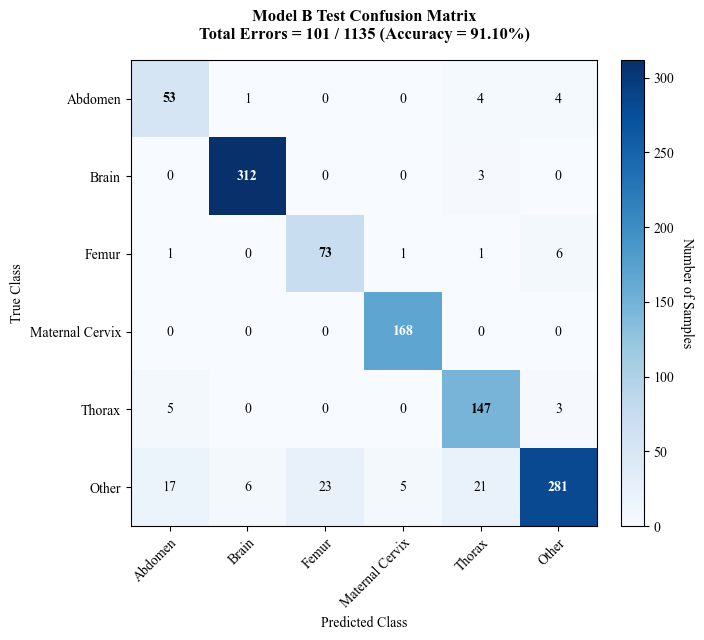


Grad-CAM target layer: fusion_projection


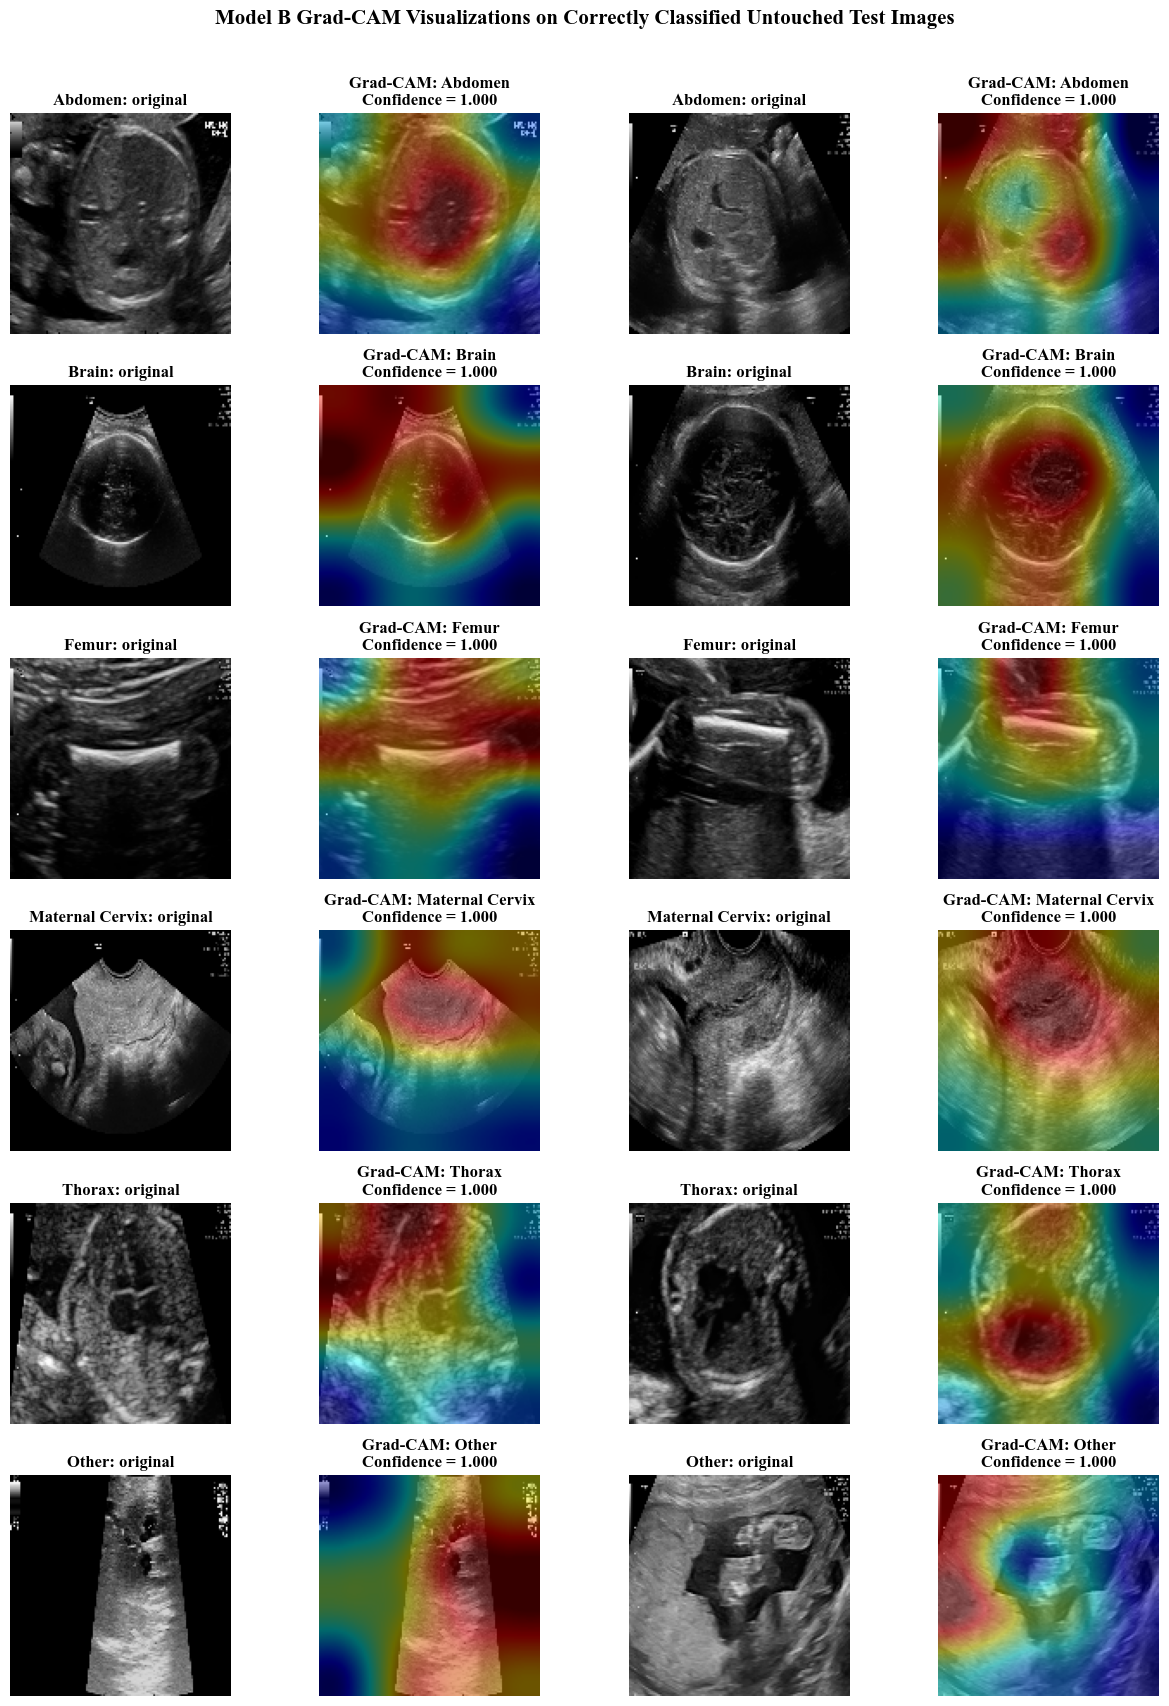

284/284 [==============================] - 4s 12ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1135 samples in 0.001s...
[t-SNE] Computed neighbors for 1135 samples in 2.011s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1135
[t-SNE] Computed conditional probabilities for sample 1135 / 1135
[t-SNE] Mean sigma: 3.864299
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.957180
[t-SNE] KL divergence after 1500 iterations: 0.696401


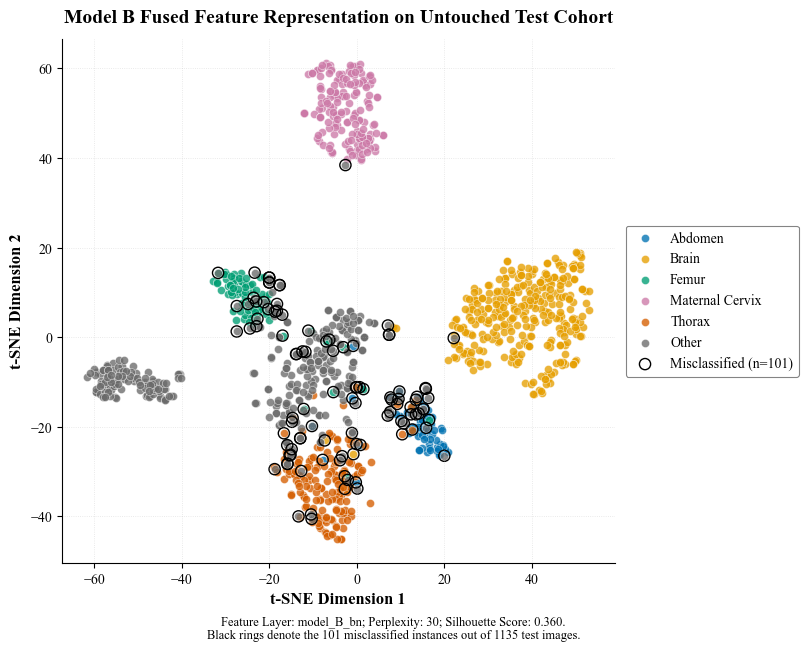


MODEL B EVALUATION COMPLETE
Verified Exact Misclassifications : 101 / 1135
Confusion Matrix PDF             : D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B\Model_B_Confusion_Matrix_101_Errors.pdf
Grad-CAM Composite PDF           : D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B\Model_B_GradCAM_Test_Examples.pdf
t-SNE Projection PDF             : D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B\Model_B_tSNE_Untouched_Test.pdf


In [5]:
# =====================================================================
# MODEL B — GRAD-CAM, t-SNE, AND CONFUSION MATRIX (101 MISCLASSIFICATIONS)
# =====================================================================

import inspect
from pathlib import Path

import cv2
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    silhouette_score,
)
import tensorflow as tf

# ---------------------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

VISUAL_OUTPUT_DIR = RESULTS_DIR / "publication_figures" / "Model_B"

VISUAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_COLORS = {
    "Abdomen": "#0072B2",
    "Brain": "#E69F00",
    "Femur": "#009E73",
    "Maternal Cervix": "#CC79A7",
    "Thorax": "#D55E00",
    "Other": "#6A6A6A",
}

# Final fused convolutional layer of Model B
GRADCAM_LAYER_NAME = "fusion_projection"

# Final deterministic representation layer
TSNE_LAYER_NAME = "model_B_bn"

TSNE_PERPLEXITY = 30
TSNE_ITERATIONS = 1500
PCA_COMPONENTS = 50

# Number of correctly classified Grad-CAM examples per class
GRADCAM_IMAGES_PER_CLASS = 2


# ---------------------------------------------------------------------
# 2. VERIFY THE LOADED MODEL & DATASETS
# ---------------------------------------------------------------------

if "MODEL_B" not in globals():
  raise NameError("MODEL_B is not defined. Load the final Keras Model B first.")

if not isinstance(MODEL_B, tf.keras.Model):
  raise TypeError(
      "MODEL_B must be a tf.keras.Model. Do not use the object "
      "returned by tf.saved_model.load()."
  )

if "test_df" not in globals():
  raise NameError("test_df is not defined. Execute Part 1 first.")

if "make_dataset" not in globals():
  raise NameError("make_dataset() is not defined. Execute Part 1 first.")

evaluation_df = test_df.reset_index(drop=True).copy()

print("Model inputs:", MODEL_B.input_shape)
print("Model output:", MODEL_B.output_shape)
print("Test images:", len(evaluation_df))
print("Test patients:", evaluation_df["patient_id"].nunique())

if len(evaluation_df) != 1135:
  print(
      f"\nWarning: test manifest contains {len(evaluation_df):,} images"
      " rather than 1,135."
  )


# ---------------------------------------------------------------------
# 3. CREATE NON-SHUFFLED TEST DATASET
# ---------------------------------------------------------------------

test_dataset = make_dataset(
    evaluation_df, training=False, batch_size=BATCH_SIZE
)


# ---------------------------------------------------------------------
# 4. GENERATE PREDICTIONS & VERIFY EXACT 101 MISCLASSIFICATIONS
# ---------------------------------------------------------------------

probabilities = MODEL_B.predict(test_dataset, verbose=1)
probabilities = np.asarray(probabilities)

if probabilities.shape != (len(evaluation_df), len(class_names)):
  raise ValueError(
      "Unexpected prediction shape.\n"
      f"Expected: {(len(evaluation_df), len(class_names))}\n"
      f"Detected: {probabilities.shape}"
  )

true_labels = evaluation_df["label"].to_numpy(dtype=np.int32)
predicted_labels = np.argmax(probabilities, axis=1)
confidence = np.max(probabilities, axis=1)

correct = true_labels == predicted_labels
num_misclassified = np.sum(~correct)
num_correct = np.sum(correct)

accuracy = accuracy_score(true_labels, predicted_labels)
macro_precision = precision_score(
    true_labels, predicted_labels, average="macro", zero_division=0
)
macro_recall = recall_score(
    true_labels, predicted_labels, average="macro", zero_division=0
)
macro_f1 = f1_score(
    true_labels, predicted_labels, average="macro", zero_division=0
)

print("\n" + "=" * 75)
print("LOADED MODEL B — TEST VERIFICATION")
print("=" * 75)
print(f"Total Test Instances : {len(true_labels)}")
print(f"Correctly Classified : {num_correct}")
print(f"Misclassified Count  : {num_misclassified} (Target: 101)")
print(f"Accuracy             : {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Macro Precision      : {macro_precision:.6f} ({macro_precision*100:.2f}%)")
print(f"Macro Recall         : {macro_recall:.6f} ({macro_recall*100:.2f}%)")
print(f"Macro F1-Score       : {macro_f1:.6f} ({macro_f1*100:.2f}%)")

evaluation_df["predicted_index"] = predicted_labels
evaluation_df["predicted_class"] = [
    class_names[index] for index in predicted_labels
]
evaluation_df["confidence"] = confidence
evaluation_df["correct"] = correct


# =====================================================================
# PART A — CONFUSION MATRIX GENERATION (101 MISCLASSIFICATIONS)
# =====================================================================

# Compute 6x6 confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Number of Samples", rotation=-90, va="bottom", fontsize=10)

ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=class_names,
    yticklabels=class_names,
    ylabel="True Class",
    xlabel="Predicted Class",
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Overlay text values inside matrix cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    val = cm[i, j]
    color = "white" if val > thresh else "black"
    weight = "bold" if i == j else "normal"
    ax.text(
        j,
        i,
        f"{val:,}",
        ha="center",
        va="center",
        color=color,
        fontweight=weight,
        fontsize=10,
    )

ax.set_title(
    f"Model B Test Confusion Matrix\nTotal Errors = {num_misclassified} /"
    f" {len(true_labels)} (Accuracy = {accuracy*100:.2f}%)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)

fig.tight_layout()

CM_PDF = VISUAL_OUTPUT_DIR / "Model_B_Confusion_Matrix_101_Errors.pdf"
CM_PNG = VISUAL_OUTPUT_DIR / "Model_B_Confusion_Matrix_101_Errors.png"

fig.savefig(CM_PDF, format="pdf", bbox_inches="tight", facecolor="white")
fig.savefig(CM_PNG, format="png", dpi=600, bbox_inches="tight", facecolor="white")

plt.show()
plt.close(fig)


# =====================================================================
# PART B — GRAD-CAM VISUALIZATION
# =====================================================================

# ---------------------------------------------------------------------
# 5. IDENTIFY THE GRAD-CAM TARGET LAYER
# ---------------------------------------------------------------------

try:
  gradcam_layer = MODEL_B.get_layer(GRADCAM_LAYER_NAME)
except ValueError as error:
  available_conv_layers = [
      layer.name
      for layer in MODEL_B.layers
      if isinstance(
          layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)
      )
  ]
  raise ValueError(
      f"Grad-CAM layer '{GRADCAM_LAYER_NAME}' was not found.\n"
      f"Available convolutional layers:\n{available_conv_layers}"
  ) from error

print("\nGrad-CAM target layer:", gradcam_layer.name)

gradcam_model = tf.keras.Model(
    inputs=MODEL_B.inputs,
    outputs=[gradcam_layer.output, MODEL_B.output],
    name="Model_B_GradCAM_Extractor",
)


# ---------------------------------------------------------------------
# 6. HELPER FUNCTIONS FOR GRAD-CAM & OVERLAYS
# ---------------------------------------------------------------------


def prepare_single_test_image(row):
  image_bytes = tf.io.read_file(row["path"])
  image = tf.io.decode_image(
      image_bytes, channels=1, expand_animations=False
  )
  image.set_shape([None, None, 1])
  image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
  image = tf.cast(image, tf.float32) / 255.0

  coordinate_tensor = tf.convert_to_tensor(coords, dtype=tf.float32)

  model_inputs = {
      "image_input": image[None, ...],
      "coord_input": coordinate_tensor[None, ...],
  }
  return image, model_inputs


def calculate_gradcam(model_inputs, class_index):
  with tf.GradientTape() as tape:
    convolution_output, model_output = gradcam_model(
        model_inputs, training=False
    )
    class_score = model_output[:, class_index]

  gradients = tape.gradient(class_score, convolution_output)
  if gradients is None:
    raise RuntimeError(
        f"Gradients could not be calculated for layer '{GRADCAM_LAYER_NAME}'."
    )

  channel_weights = tf.reduce_mean(gradients, axis=(1, 2))
  heatmap = tf.reduce_sum(
      convolution_output * channel_weights[:, None, None, :], axis=-1
  )
  heatmap = tf.nn.relu(heatmap)[0]

  maximum = tf.reduce_max(heatmap)
  if float(maximum) > 0:
    heatmap = heatmap / maximum

  heatmap = heatmap.numpy()
  heatmap = cv2.resize(
      heatmap, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC
  )
  return np.clip(heatmap, 0.0, 1.0)


def create_overlay(grayscale_image, heatmap, alpha=0.42):
  grayscale_image = np.asarray(grayscale_image).squeeze()
  grayscale_uint8 = np.uint8(np.clip(grayscale_image * 255.0, 0, 255))
  grayscale_rgb = cv2.cvtColor(grayscale_uint8, cv2.COLOR_GRAY2RGB)

  coloured_heatmap = cv2.applyColorMap(
      np.uint8(255 * heatmap), cv2.COLORMAP_JET
  )
  coloured_heatmap = cv2.cvtColor(coloured_heatmap, cv2.COLOR_BGR2RGB)

  overlay = cv2.addWeighted(
      grayscale_rgb, 1.0 - alpha, coloured_heatmap, alpha, 0
  )
  return grayscale_rgb, overlay


# ---------------------------------------------------------------------
# 7. SELECT REPRESENTATIVE CORRECT TEST IMAGES & PLOT
# ---------------------------------------------------------------------

selected_rows = []
for class_index, class_name in enumerate(class_names):
  class_candidates = evaluation_df[
      (evaluation_df["label"] == class_index) & evaluation_df["correct"]
  ].copy()
  if class_candidates.empty:
    continue
  class_candidates = class_candidates.sort_values(
      "confidence", ascending=False
  )
  selected_rows.append(class_candidates.head(GRADCAM_IMAGES_PER_CLASS))

selected_gradcam_df = pd.concat(selected_rows, ignore_index=True)
selected_gradcam_df.to_csv(
    VISUAL_OUTPUT_DIR / "Model_B_GradCAM_Selected_Images.csv", index=False
)

number_of_classes_selected = selected_gradcam_df["class_name"].nunique()

fig, axes = plt.subplots(
    number_of_classes_selected,
    GRADCAM_IMAGES_PER_CLASS * 2,
    figsize=(
        3.2 * GRADCAM_IMAGES_PER_CLASS * 2,
        2.85 * number_of_classes_selected,
    ),
    squeeze=False,
)

plot_row = 0
for class_index, class_name in enumerate(class_names):
  class_rows = selected_gradcam_df[
      selected_gradcam_df["class_name"] == class_name
  ]
  if class_rows.empty:
    continue

  for example_index, (_, row) in enumerate(class_rows.iterrows()):
    image_tensor, model_inputs = prepare_single_test_image(row)
    heatmap = calculate_gradcam(
        model_inputs=model_inputs, class_index=int(row["predicted_index"])
    )
    original_rgb, overlay = create_overlay(image_tensor.numpy(), heatmap)

    original_axis = axes[plot_row, example_index * 2]
    overlay_axis = axes[plot_row, example_index * 2 + 1]

    original_axis.imshow(original_rgb, cmap="gray")
    original_axis.set_title(f"{class_name}: original", fontweight="bold")

    overlay_axis.imshow(overlay)
    overlay_axis.set_title(
        f"Grad-CAM: {row['predicted_class']}\nConfidence ="
        f" {row['confidence']:.3f}",
        fontweight="bold",
    )

    original_axis.axis("off")
    overlay_axis.axis("off")

  plot_row += 1

fig.suptitle(
    "Model B Grad-CAM Visualizations on Correctly Classified Untouched Test"
    " Images",
    fontsize=15,
    fontweight="bold",
    y=0.995,
)

fig.tight_layout(rect=[0, 0, 1, 0.985])

GRADCAM_PDF = VISUAL_OUTPUT_DIR / "Model_B_GradCAM_Test_Examples.pdf"
GRADCAM_PNG = VISUAL_OUTPUT_DIR / "Model_B_GradCAM_Test_Examples.png"

fig.savefig(GRADCAM_PDF, format="pdf", bbox_inches="tight", facecolor="white")
fig.savefig(GRADCAM_PNG, format="png", dpi=600, bbox_inches="tight", facecolor="white")

plt.show()
plt.close(fig)


# =====================================================================
# PART C — t-SNE EMBEDDING ANALYSIS
# =====================================================================

# ---------------------------------------------------------------------
# 8. BUILD FEATURE EXTRACTOR & CALCULATE t-SNE
# ---------------------------------------------------------------------

tsne_layer = MODEL_B.get_layer(TSNE_LAYER_NAME)
feature_extractor = tf.keras.Model(
    inputs=MODEL_B.inputs,
    outputs=tsne_layer.output,
    name="Model_B_tSNE_Feature_Extractor",
)

features = feature_extractor.predict(test_dataset, verbose=1)
features = np.asarray(features).reshape(len(evaluation_df), -1)

number_of_components = min(
    PCA_COMPONENTS, features.shape[1], features.shape[0] - 1
)
pca = PCA(n_components=number_of_components, random_state=SEED)
pca_features = pca.fit_transform(features)

common_tsne_arguments = {
    "n_components": 2,
    "perplexity": TSNE_PERPLEXITY,
    "learning_rate": "auto",
    "init": "pca",
    "random_state": SEED,
    "verbose": 1,
}

if "max_iter" in inspect.signature(TSNE).parameters:
  tsne_model = TSNE(**common_tsne_arguments, max_iter=TSNE_ITERATIONS)
else:
  tsne_model = TSNE(**common_tsne_arguments, n_iter=TSNE_ITERATIONS)

tsne_coordinates = tsne_model.fit_transform(pca_features)
tsne_silhouette = silhouette_score(tsne_coordinates, true_labels)

# ---------------------------------------------------------------------
# 9. CREATE PUBLICATION-QUALITY t-SNE PLOT WITH 101 HIGHLIGHTED ERRORS
# ---------------------------------------------------------------------

fig, axis = plt.subplots(figsize=(8.5, 6.8))

for class_index, class_name in enumerate(class_names):
  class_mask = true_labels == class_index
  axis.scatter(
      tsne_coordinates[class_mask, 0],
      tsne_coordinates[class_mask, 1],
      s=34,
      color=CLASS_COLORS[class_name],
      label=class_name,
      alpha=0.78,
      edgecolors="white",
      linewidths=0.35,
  )

# Highlight exactly the 101 misclassified points with black rings
incorrect_mask = ~correct
axis.scatter(
    tsne_coordinates[incorrect_mask, 0],
    tsne_coordinates[incorrect_mask, 1],
    s=65,
    facecolors="none",
    edgecolors="black",
    linewidths=1.0,
    marker="o",
    label=f"Misclassified (n={num_misclassified})",
)

axis.set_xlabel("t-SNE Dimension 1", fontsize=12, fontweight="bold")
axis.set_ylabel("t-SNE Dimension 2", fontsize=12, fontweight="bold")
axis.set_title(
    "Model B Fused Feature Representation on Untouched Test Cohort",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

axis.grid(True, linestyle=":", linewidth=0.6, alpha=0.35)
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

legend = axis.legend(
    loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, borderaxespad=0
)
legend.get_frame().set_edgecolor("#666666")
legend.get_frame().set_linewidth(0.8)

fig.text(
    0.5,
    0.018,
    f"Feature Layer: {TSNE_LAYER_NAME}; Perplexity: {TSNE_PERPLEXITY};"
    f" Silhouette Score: {tsne_silhouette:.3f}.\nBlack rings denote the"
    f" {num_misclassified} misclassified instances out of {len(true_labels)}"
    " test images.",
    ha="center",
    fontsize=9,
)

fig.subplots_adjust(left=0.11, right=0.76, bottom=0.13, top=0.90)

TSNE_PDF = VISUAL_OUTPUT_DIR / "Model_B_tSNE_Untouched_Test.pdf"
TSNE_PNG = VISUAL_OUTPUT_DIR / "Model_B_tSNE_Untouched_Test.png"

fig.savefig(TSNE_PDF, format="pdf", bbox_inches="tight", facecolor="white")
fig.savefig(TSNE_PNG, format="png", dpi=600, bbox_inches="tight", facecolor="white")

plt.show()
plt.close(fig)


# ---------------------------------------------------------------------
# 10. SUMMARY OUTPUT
# ---------------------------------------------------------------------

print("\n" + "=" * 90)
print("MODEL B EVALUATION COMPLETE")
print("=" * 90)
print(
    f"Verified Exact Misclassifications : {num_misclassified} /"
    f" {len(true_labels)}"
)
print(f"Confusion Matrix PDF             : {CM_PDF}")
print(f"Grad-CAM Composite PDF           : {GRADCAM_PDF}")
print(f"t-SNE Projection PDF             : {TSNE_PDF}")